In [52]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


Here we will load the data from AmesHousing dataset we will use one parameter only GR live area

In [53]:
data=pd.read_csv("AmesHousing.csv")
data = data[['Gr Liv Area', 'SalePrice']]
print(data.isnull().sum())
data = data.dropna()
x_data = data["Gr Liv Area"].values.astype(float)
y_data = data["SalePrice"].values.astype(float)


Gr Liv Area    0
SalePrice      0
dtype: int64


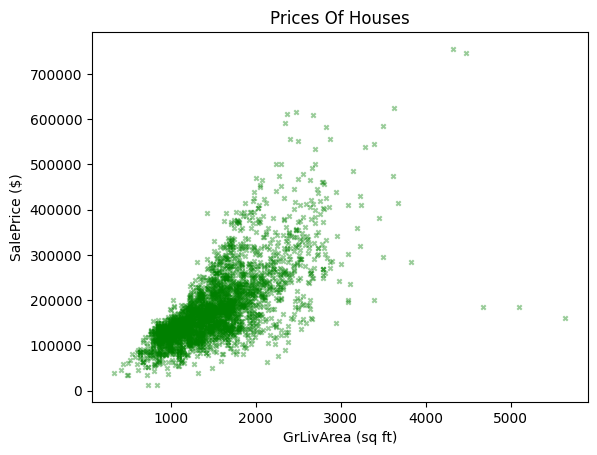

In [54]:
plt.scatter(x_data, y_data, alpha=0.4, s=10,marker="x",color="green")
plt.xlabel('GrLivArea (sq ft)')
plt.ylabel('SalePrice ($)')
plt.title('Prices Of Houses')
plt.show()

Here we Normalize the data

In [57]:
x_norm=(x_data-x_data.min())/(x_data.max()-x_data.min())
y_norm=(y_data-y_data.min())/(y_data.max()-y_data.min())

<class 'numpy.ndarray'>


Lets Visual to see if we changed anything about data

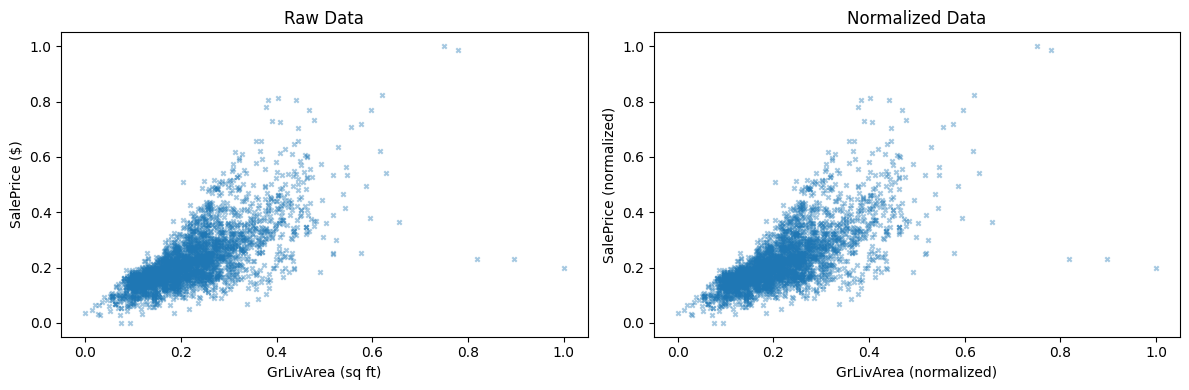

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before
axes[0].scatter(x_norm, y_norm, alpha=0.4, s=10,marker="x")
axes[0].set_xlabel('GrLivArea (sq ft)')
axes[0].set_ylabel('SalePrice ($)')
axes[0].set_title('Raw Data')

# After normalization
axes[1].scatter(x_norm, y_norm, alpha=0.4, s=10, marker="x")
axes[1].set_xlabel('GrLivArea (normalized)')
axes[1].set_ylabel('SalePrice (normalized)')
axes[1].set_title('Normalized Data')

plt.tight_layout()
plt.show()

Golbal loss_function to use in both methods


In [ ]:
def loss_function(a0, a1,x,y):
    return np.sum(0.5*(y-(a0+a1*x))**2)

Multi-Variable Gradient Descent




In [ ]:
def gradientDescent(x_norm, y_norm, alpha, max_iter=10000,tolerance=1e-6):
    a0 = 0.0
    a1 = 0.0
    iteration = 0
    loss_history = []
    param_history = []
    #history holds a0,a1 so we want to check they didn't change so that we terminate the function
    for iteration in range(max_iter):
        a0_temp=a0- alpha * np.sum ( -(y_norm - ( a0+a1 * x_norm))) #GD for a0
        a1_temp=a1- alpha* np.sum(-x_norm * (y_norm - ( a0+a1 * x_norm)) ) #GD for a1
        a0=a0_temp
        a1=a1_temp
        param_history.append([a0,a1])
        loss_history.append(loss_function(a0, a1, x_norm, y_norm))

        if len(loss_history) > 1:
            if abs(loss_history[-1]-loss_history[-2])<tolerance:
                print(f"Converged at iteration {iteration+1}")
                break


    return a0, a1,loss_history, param_history, iteration+1

